# SVM: re-evaluation

Re-run of `svm.ipynb` (originally `kula.ipynb`), whose 96% was not comparable with the other models. Three variants, so the effect of the split and of the features can be seen separately:

| Variant | Features | Split | Question it answers |
|---|---|---|---|
| **A** | one frame: raw (x, y, depth, confidence) + frame number | random over frames, 80/20 | Does the original protocol still give a high number on 41 recordings? |
| **B** | same as A | recording-level 5-fold × 3 | What is left when the test recordings are unseen? |
| **C** | displacement windows, flattened (same as Random Forest) | recording-level 5-fold × 3 | How does the SVM compare with the other models on equal terms? |

**Same as the original:** the grid search over `kernel ∈ {linear, poly, rbf, sigmoid}`, `C ∈ {0.001, 0.005, 0.1, 0.5, 1}`, `gamma ∈ {scale, auto}`.

**Different from the original:** features are standardised inside the pipeline (for all three variants, so A and B differ only in the split), the data is the 41 surviving recordings with 6 classes, and in B and C the grid search uses grouped inner folds, so tuning never sees the test recordings either.

**Evaluation protocol (shared by every `reeval_*` notebook, see `src/reeval_common.py`):**

- Data: `data/keypoint_sequences.csv`, 41 Kinect recordings that survived; the larger folder the thesis notebooks used is lost.
- 6 classes, as in the thesis models: `squat_front` and `squat_side` are merged into `squat`.
- Stratified 5-fold cross-validation over **recordings**, repeated with 3 shuffles (15 splits). All windows of a recording are on the same side of every split.
- Nothing from a test fold is used for training, hyperparameter search or early stopping.
- Reported per split: window accuracy, macro F1, accuracy after a majority vote per recording (what the real-time system does), and a majority-class baseline.
- The spread across splits is shown as ± one standard deviation. Splits share recordings, so this understates the true uncertainty; with 41 recordings, differences of a few points are not meaningful.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "keypoint_sequences.csv").exists())
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import reeval_common as rc

records = rc.load_recordings()
table = rc.recordings_table(records)
table.groupby("label").agg(recordings=("rec_id", "count"), frames=("n_frames", "sum"))

,recordings,frames
label,,
bent-over_rows,6,456
biceps,6,456
latheral_raises,6,455
rdl,6,455
shoulder_press,6,456
squat,11,836


In [2]:
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

PARAM_GRID = {
    "svc__kernel": ["linear", "poly", "rbf", "sigmoid"],
    "svc__C": [0.001, 0.005, 0.1, 0.5, 1],
    "svc__gamma": ["scale", "auto"],
}


def search(cv):
    return GridSearchCV(make_pipeline(StandardScaler(), SVC()), PARAM_GRID, cv=cv, scoring="accuracy", n_jobs=-1)


best_params = {"A": [], "B": [], "C": []}


def fit_predict_random(X_train, y_train, groups_train, X_test, seed):
    s = search(cv=5)  # the original: 5 folds over frames
    s.fit(X_train, y_train)
    best_params["A"].append(s.best_params_)
    return s.predict(X_test)


def grouped(variant):
    def fit_predict(X_train, y_train, groups_train, X_test, seed):
        s = search(cv=GroupKFold(n_splits=4))
        s.fit(X_train, y_train, groups=groups_train)
        best_params[variant].append(s.best_params_)
        return s.predict(X_test)
    return fit_predict

## A: original protocol (random frame split)

In [3]:
Xf, yf, gf = rc.single_frames(records, with_frame_number=True)
print("frames:", Xf.shape)
result_a = rc.evaluate(
    fit_predict_random, Xf, yf, gf, rc.random_sample_splits(len(yf)),
    model="SVM", variant="A: single frames", split="random frame split 80/20 × 3 (leaky)",
    features="raw x, y, depth, confidence + frame number (101)", params="grid search, 5 random folds",
)
result_a["best_params"] = best_params["A"]
rc.save_results(result_a, "svm_a_frames_random_split")
rc.summary_table([result_a])

frames: (3114, 101)


,model,variant,split,samples,splits run,accuracy,macro F1,recording vote,majority baseline
0,SVM,A: single frames,random frame split 80/20 × 3 (leaky),3114,3,97.6% ± 0.8%,97.4% ± 0.9%,99.2% ± 1.4%,27.2%


## B: same features, recording-level split

In [4]:
result_b = rc.evaluate(
    grouped("B"), Xf, yf, gf, rc.recording_splits(gf, records),
    model="SVM", variant="B: single frames", split="recording-level 5-fold × 3",
    features="raw x, y, depth, confidence + frame number (101)", params="grid search, grouped inner folds",
)
result_b["best_params"] = best_params["B"]
rc.save_results(result_b, "svm_b_frames_recording_split")
rc.summary_table([result_b])

,model,variant,split,samples,splits run,accuracy,macro F1,recording vote,majority baseline
0,SVM,B: single frames,recording-level 5-fold × 3,3114,15,58.7% ± 11.4%,55.2% ± 10.8%,63.7% ± 16.6%,26.7%


## C: displacement windows, recording-level split

In [5]:
X, y, groups = rc.displacement_windows(records)
print("windows:", X.shape, "(windows, steps, keypoints, dx/dy)")
pd.Series(y).value_counts().rename("windows").to_frame()

windows: (121, 25, 25, 2) (windows, steps, keypoints, dx/dy)


,windows
squat,33
bent-over_rows,18
biceps,18
shoulder_press,18
latheral_raises,17
rdl,17


In [6]:
Xw = X.reshape(len(X), -1)
result_c = rc.evaluate(
    grouped("C"), Xw, y, groups, rc.recording_splits(groups, records),
    model="SVM", variant="C: windows", split="recording-level 5-fold × 3",
    features="displacement windows, flattened (1,250)", params="grid search, grouped inner folds",
)
result_c["best_params"] = best_params["C"]
rc.save_results(result_c, "svm_c_windows_recording_split")
rc.summary_table([result_c])

,model,variant,split,samples,splits run,accuracy,macro F1,recording vote,majority baseline
0,SVM,C: windows,recording-level 5-fold × 3,121,15,38.4% ± 5.1%,19.3% ± 2.8%,37.2% ± 7.4%,27.1%


## All three variants

In [7]:
rc.summary_table([result_a, result_b, result_c])

,model,variant,split,samples,splits run,accuracy,macro F1,recording vote,majority baseline
0,SVM,A: single frames,random frame split 80/20 × 3 (leaky),3114,3,97.6% ± 0.8%,97.4% ± 0.9%,99.2% ± 1.4%,27.2%
1,SVM,B: single frames,recording-level 5-fold × 3,3114,15,58.7% ± 11.4%,55.2% ± 10.8%,63.7% ± 16.6%,26.7%
2,SVM,C: windows,recording-level 5-fold × 3,121,15,38.4% ± 5.1%,19.3% ± 2.8%,37.2% ± 7.4%,27.1%


In [8]:
pd.DataFrame(
    {v: pd.Series([str(sorted(p.items())) for p in best_params[v]]).value_counts() for v in best_params}
).fillna(0).astype(int)

,A,B,C
"[('svc__C', 0.005), ('svc__gamma', 'scale'), ('svc__kernel', 'linear')]",0,1,0
"[('svc__C', 0.1), ('svc__gamma', 'scale'), ('svc__kernel', 'linear')]",0,2,1
"[('svc__C', 0.1), ('svc__gamma', 'scale'), ('svc__kernel', 'sigmoid')]",0,1,0
"[('svc__C', 0.5), ('svc__gamma', 'scale'), ('svc__kernel', 'linear')]",2,3,0
"[('svc__C', 0.5), ('svc__gamma', 'scale'), ('svc__kernel', 'rbf')]",0,0,13
"[('svc__C', 0.5), ('svc__gamma', 'scale'), ('svc__kernel', 'sigmoid')]",0,2,0
"[('svc__C', 1), ('svc__gamma', 'scale'), ('svc__kernel', 'linear')]",0,4,0
"[('svc__C', 1), ('svc__gamma', 'scale'), ('svc__kernel', 'rbf')]",1,1,1
"[('svc__C', 1), ('svc__gamma', 'scale'), ('svc__kernel', 'sigmoid')]",0,1,0


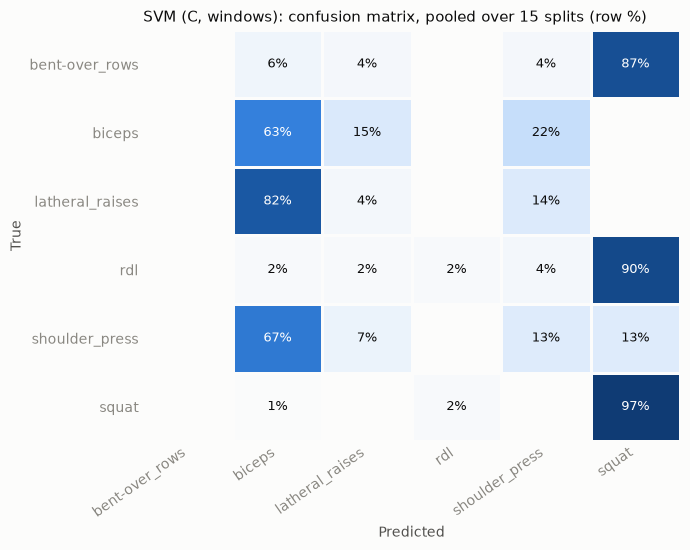

In [9]:
rc.plot_confusion(result_c, "SVM (C, windows): confusion matrix, pooled over 15 splits (row %)", "svm_c_confusion.png");